<a href="https://colab.research.google.com/github/yashdeepspodder23/BlackHoleSimulations/blob/main/BHSim3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Spin Parameter (a): 0.95
Event Horizon (Rh): 6.56
ISCO Radius (R_isco): 9.69


/tmp/ipykernel_6024/4041907212.py:93: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  horizon_sphere = plt.Circle(bh_pos, Rh, color='#0a0a0a', edgecolor='magenta', lw=1.5, zorder=2, label=f'Spinning Horizon ($R_h$, a={a})')


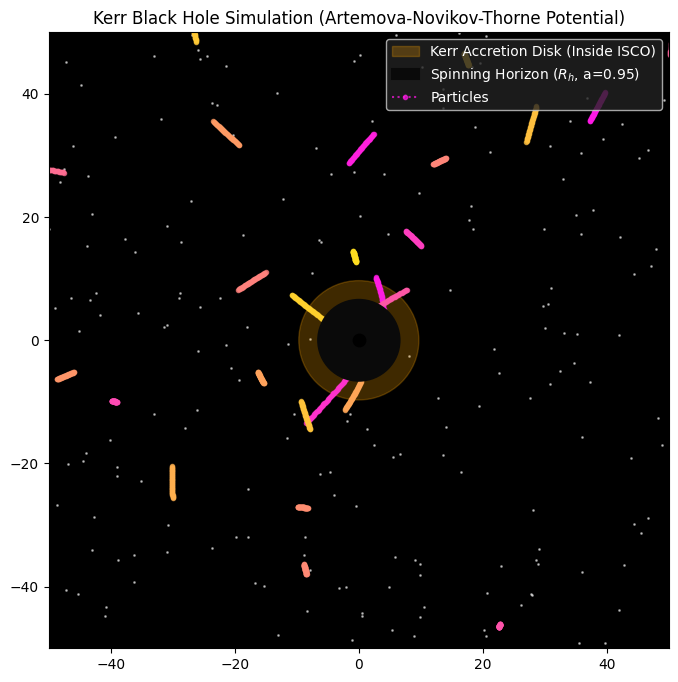

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import collections

# =====================================================================
# CONSTANTS & ARTEMOVA-NOVIKOV-THORNE SPIN PARAMETERS
# =====================================================================
G = 1        # Gravitational constant
M = 5.0      # Mass of the black hole
dt = 0.075    # Time step
num_p = 50   # Number of particles

# Dimensionless Spin Parameter (a): 0 is static, 0.999 is max spin
a = 0.95

# Kerr Metric algebraic approximations for Horizon and ISCO (in units of M)
Z1 = 1 + (1 - a**2)**(1/3) * ((1 + a)**(1/3) + (1 - a)**(1/3))
Z2 = np.sqrt(3 * a**2 + Z1**2)
r_isco_units = 3 + Z2 - np.sqrt((3 - Z1) * (3 + Z1 + 2 * Z2))
r_h_units = 1 + np.sqrt(1 - a**2)

# Scale to physical system mass M
Rh = r_h_units * M        # Event Horizon Radius
R_isco = r_isco_units * M  # Innermost Stable Circular Orbit
gamma = (R_isco / Rh) - 1  # ANT Scaling exponent

print(f"Spin Parameter (a): {a}")
print(f"Event Horizon (Rh): {Rh:.2f}")
print(f"ISCO Radius (R_isco): {R_isco:.2f}")

# Initialize particle positions and velocities
np.random.seed(100)
poss = np.random.uniform(-40, 40, (num_p, 2))
# Tangential velocities initialized to give them initial angular momentum
vel = np.random.uniform(-2, 2, (num_p, 2))

# Black hole position
bh_pos = np.array([0, 0])

# Global variables for trail
trail_length = 50
trail_data = [collections.deque(maxlen=trail_length) for _ in range(num_p)]

# =====================================================================
# ARTEMOVA-NOVIKOV-THORNE FORCE CALCULATION
# =====================================================================
def grav_force_ant(pos):
    r = np.linalg.norm(pos - bh_pos)

    # Capture Condition: Crossed the spinning horizon boundary
    if r <= Rh + 1e-2:
        return None

    # ANT Force Equation: F = GM / [ r^2 * (1 - Rh/r)^gamma ]
    f_mag = (G * M) / (r**2 * (1.0 - Rh / r)**gamma)
    dirn = (bh_pos - pos) / r
    return f_mag * dirn

# Update particle positions and velocities
def update_particles(poss, vel):
    for i in range(len(poss)):
        f = grav_force_ant(poss[i])

        if f is None:
            # Particle swallowed: Lock into the singularity core
            poss[i] = np.array([0.0, 0.0])
            vel[i] = np.array([0.0, 0.0])
        else:
            vel[i] += f * dt
            poss[i] += vel[i] * dt
    return poss, vel

# =====================================================================
# LAYERING SETUP & PLOT REGIME
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-50, 50)
ax.set_ylim(-50, 50)
ax.set_facecolor('black')

# Static background stars
num_stars = 200
star_x = np.random.uniform(-50, 50, num_stars)
star_y = np.random.uniform(-50, 50, num_stars)
ax.scatter(star_x, star_y, s=1, color='white', alpha=0.5, zorder=0)

# Accretion Disk customized to the spinning ISCO boundary
accretion_disk = plt.Circle(bh_pos, R_isco, color='orange', alpha=0.25, zorder=1, label='Kerr Accretion Disk (Inside ISCO)')
ax.add_patch(accretion_disk)

# Spinning Event Horizon marker
horizon_sphere = plt.Circle(bh_pos, Rh, color='#0a0a0a', edgecolor='magenta', lw=1.5, zorder=2, label=f'Spinning Horizon ($R_h$, a={a})')
ax.add_patch(horizon_sphere)

# Singularity
bh = plt.scatter(*bh_pos, color='black', s=80, zorder=3)

# Build trail lines
particles_trails = []
colors = plt.cm.spring(np.linspace(0.1, 0.9, num_p)) # High energy coloring
for i in range(num_p):
    if i == 0:
        line, = ax.plot([], [], 'o:', color=colors[i], markersize=3, alpha=0.7, label='Particles', zorder=1.5)
    else:
        line, = ax.plot([], [], 'o:', color=colors[i], markersize=3, alpha=0.7, zorder=1.5)
    particles_trails.append(line)

ax.legend(loc='upper right', facecolor='#222222', labelcolor='white')
plt.title('Kerr Black Hole Simulation (Artemova-Novikov-Thorne Potential)', color='black')

# =====================================================================
# ANIMATION LOOP
# =====================================================================
def init():
    for line in particles_trails:
        line.set_data([], [])
    return particles_trails

def animate(frame):
    global poss, vel
    poss, vel = update_particles(poss, vel)

    for i in range(num_p):
        if not np.all(poss[i] == 0.0):
            trail_data[i].append(poss[i].copy())

    artists_to_return = []
    for i, line in enumerate(particles_trails):
        x_coords = [p[0] for p in trail_data[i]]
        y_coords = [p[1] for p in trail_data[i]]
        line.set_data(x_coords, y_coords)
        artists_to_return.append(line)

    return artists_to_return

ani = FuncAnimation(fig, animate, frames=600, init_func=init, interval=20, blit=True)
#plt.show()

from IPython.display import HTML
html_animation = HTML(ani.to_html5_video())
display(html_animation)